# Experiment 1 — headline benchmark (PD)

5-fold CV on the 14 PD datasets. For each quantity — **AUC**, **Brier**, **F1** — the same three views: dataset×method **matrix** (best column left), per-method **bar** (value above; **fold-level** std error bars), and a **box** plot of the across-dataset spread. Then **compute time**, the **per-dataset rank (AUC)**, the **HPO effect on AUC**, and the **performance-vs-compute** frontier. Foundation-model names are red. Figures → `figures/experiment1/pd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/pd')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment1\pd


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False, hpo_mode='HPO')              # per-fold, HPO (tuned models + their compute times)
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='pd', aggregated=False, hpo_mode=None)
print(f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

34 methods x 14 datasets


## AUC

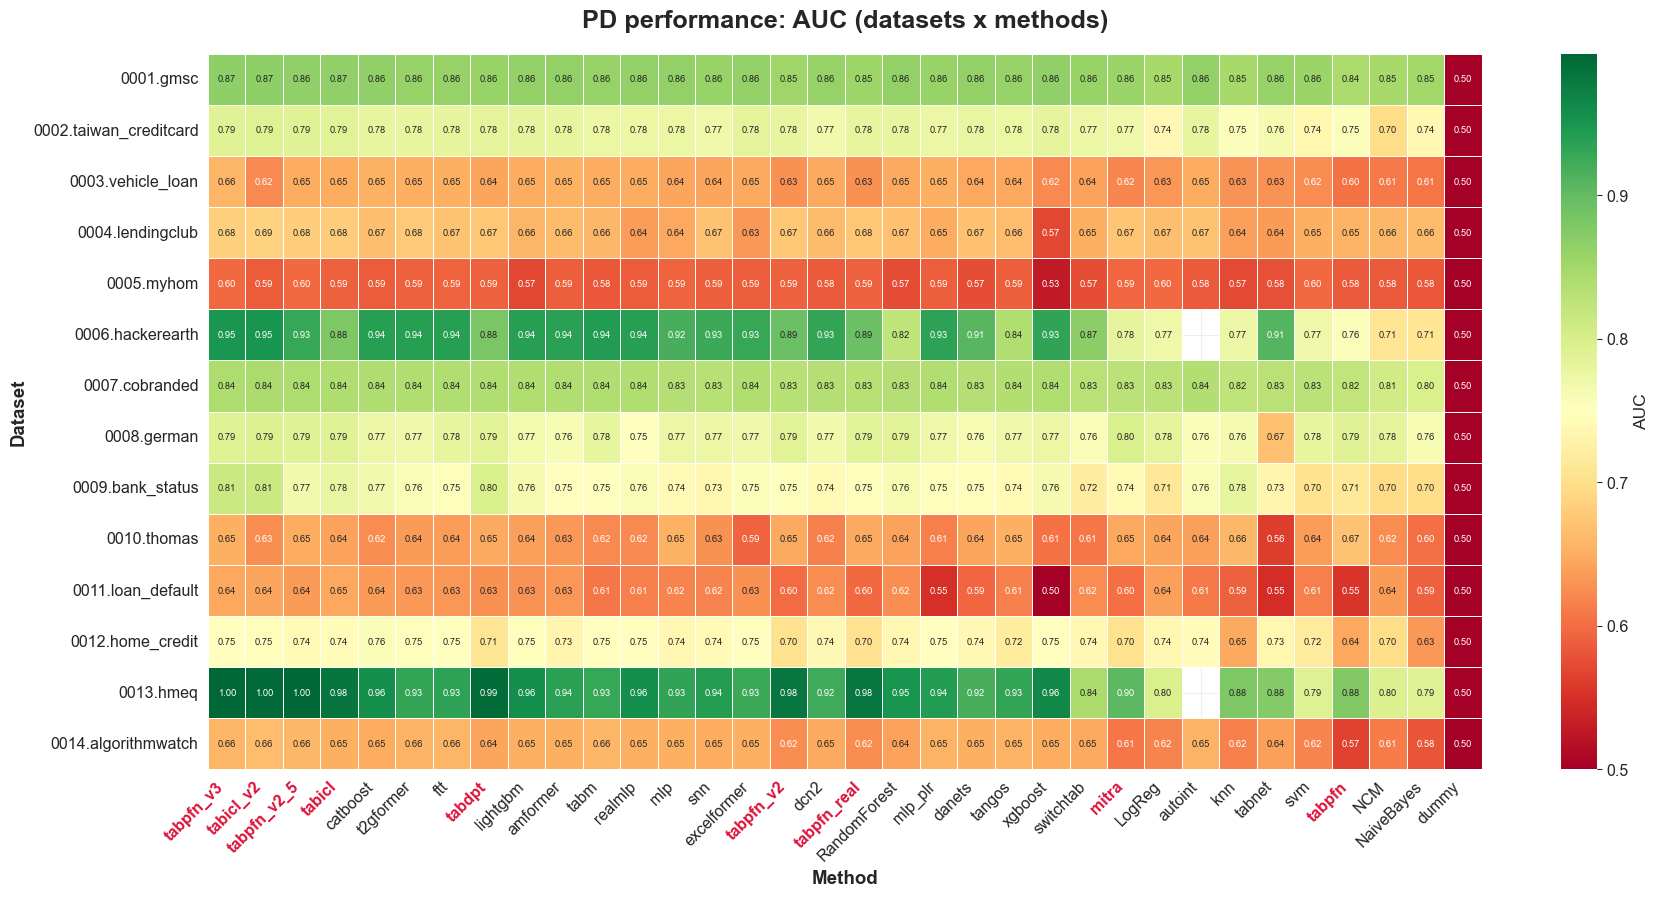

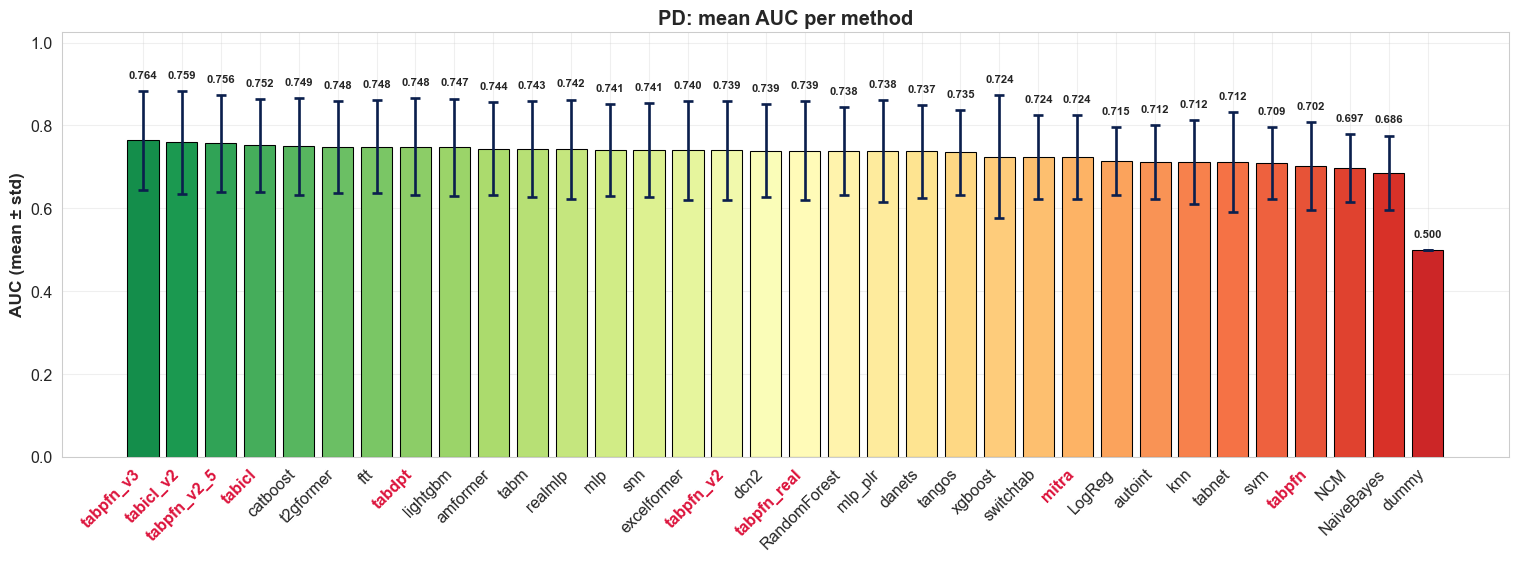

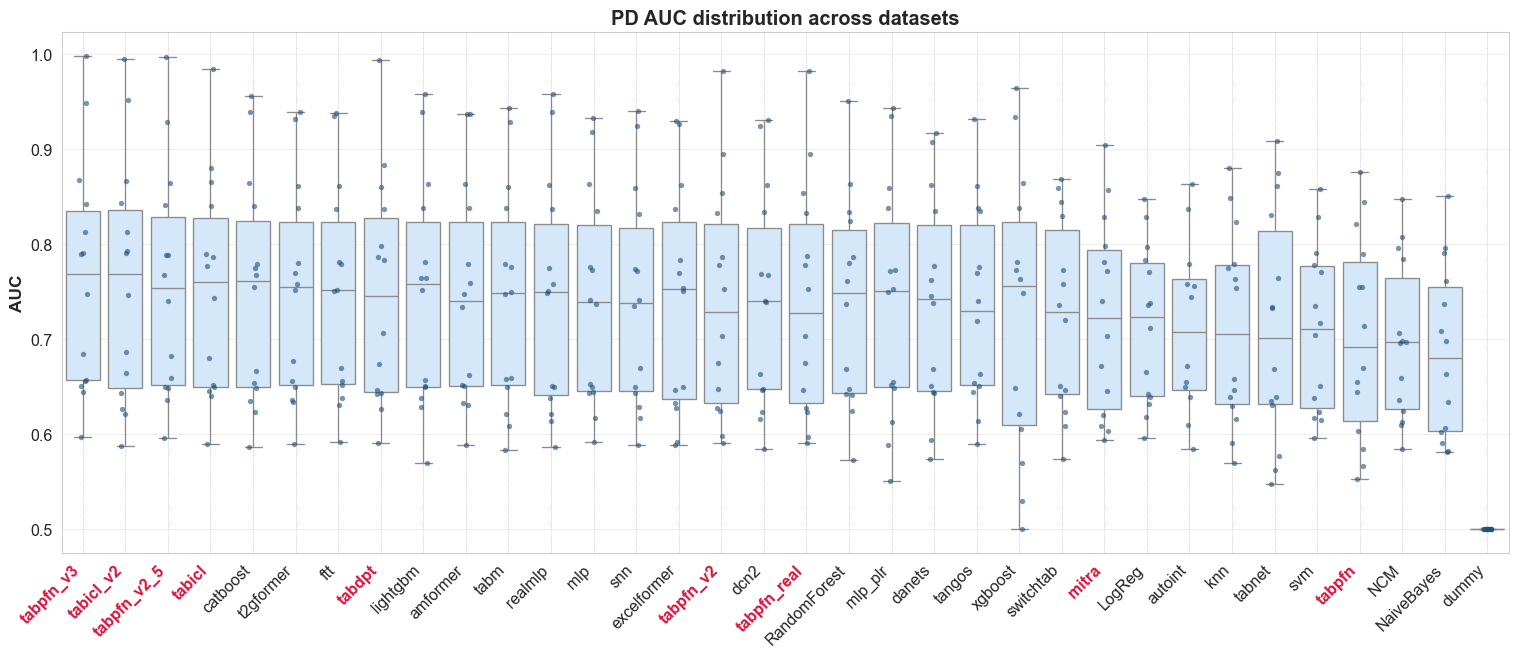

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_auc.pdf')

In [3]:
performance_heatmap(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)

## Brier score (lower is better)

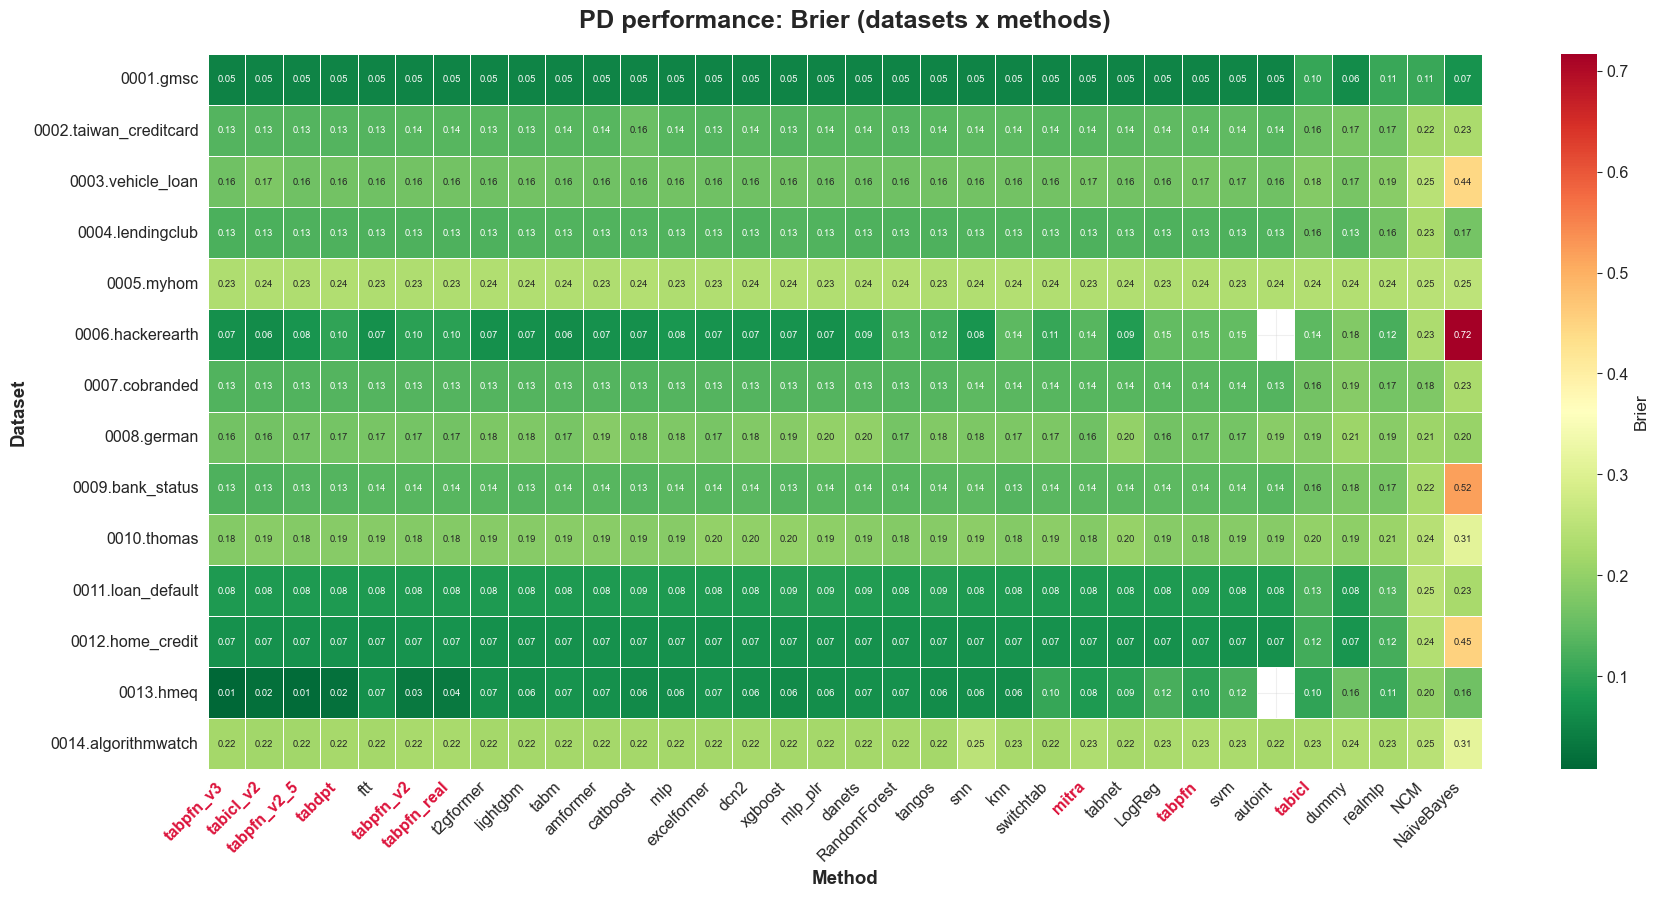

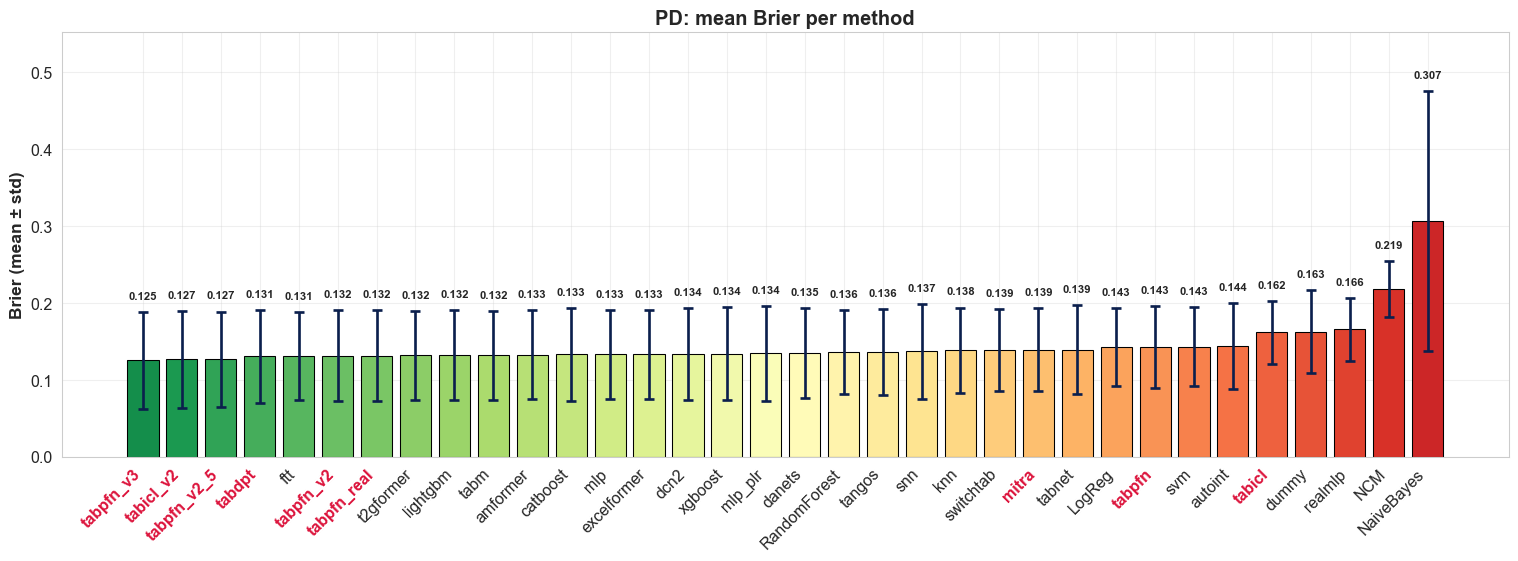

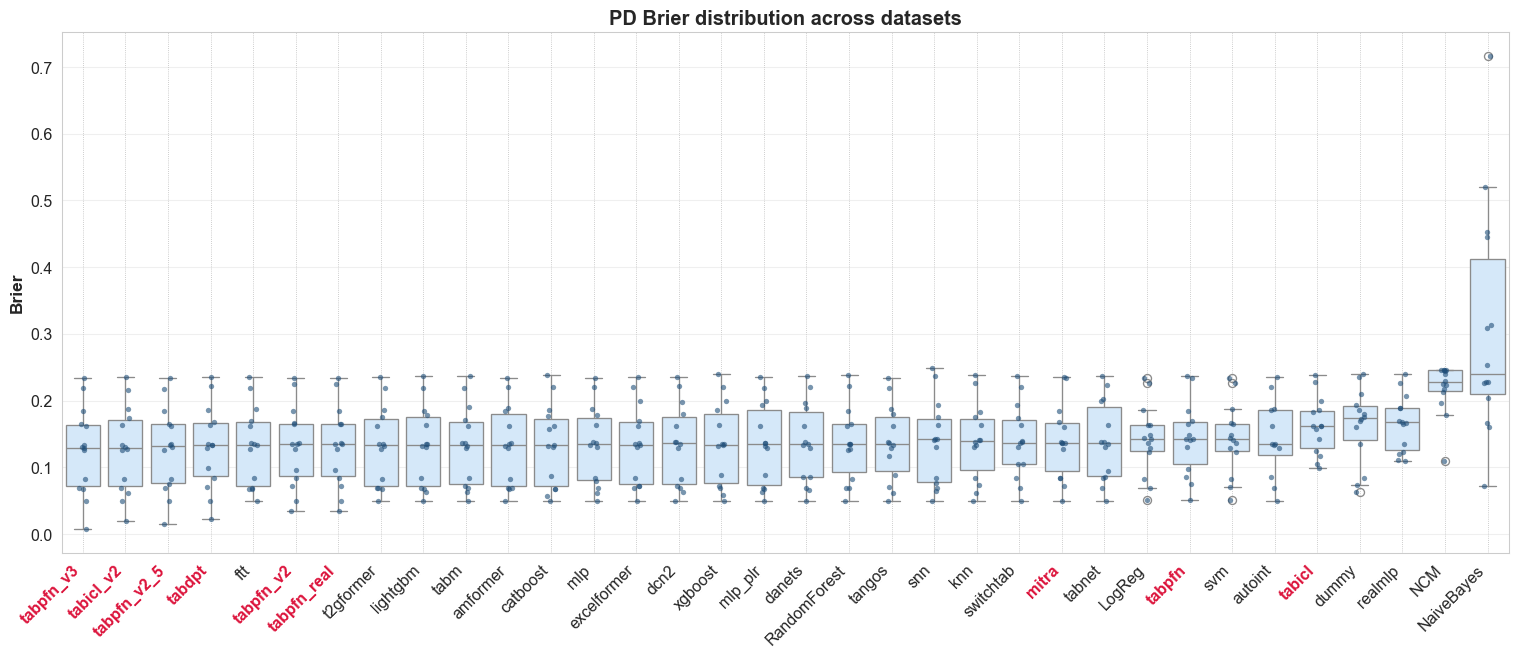

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_brier.pdf')

In [4]:
performance_heatmap(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_bars(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)
metric_boxplots(df, 'Brier', task_name='PD', higher_is_better=False, out_dir=FIGURES_DIR)

## F1

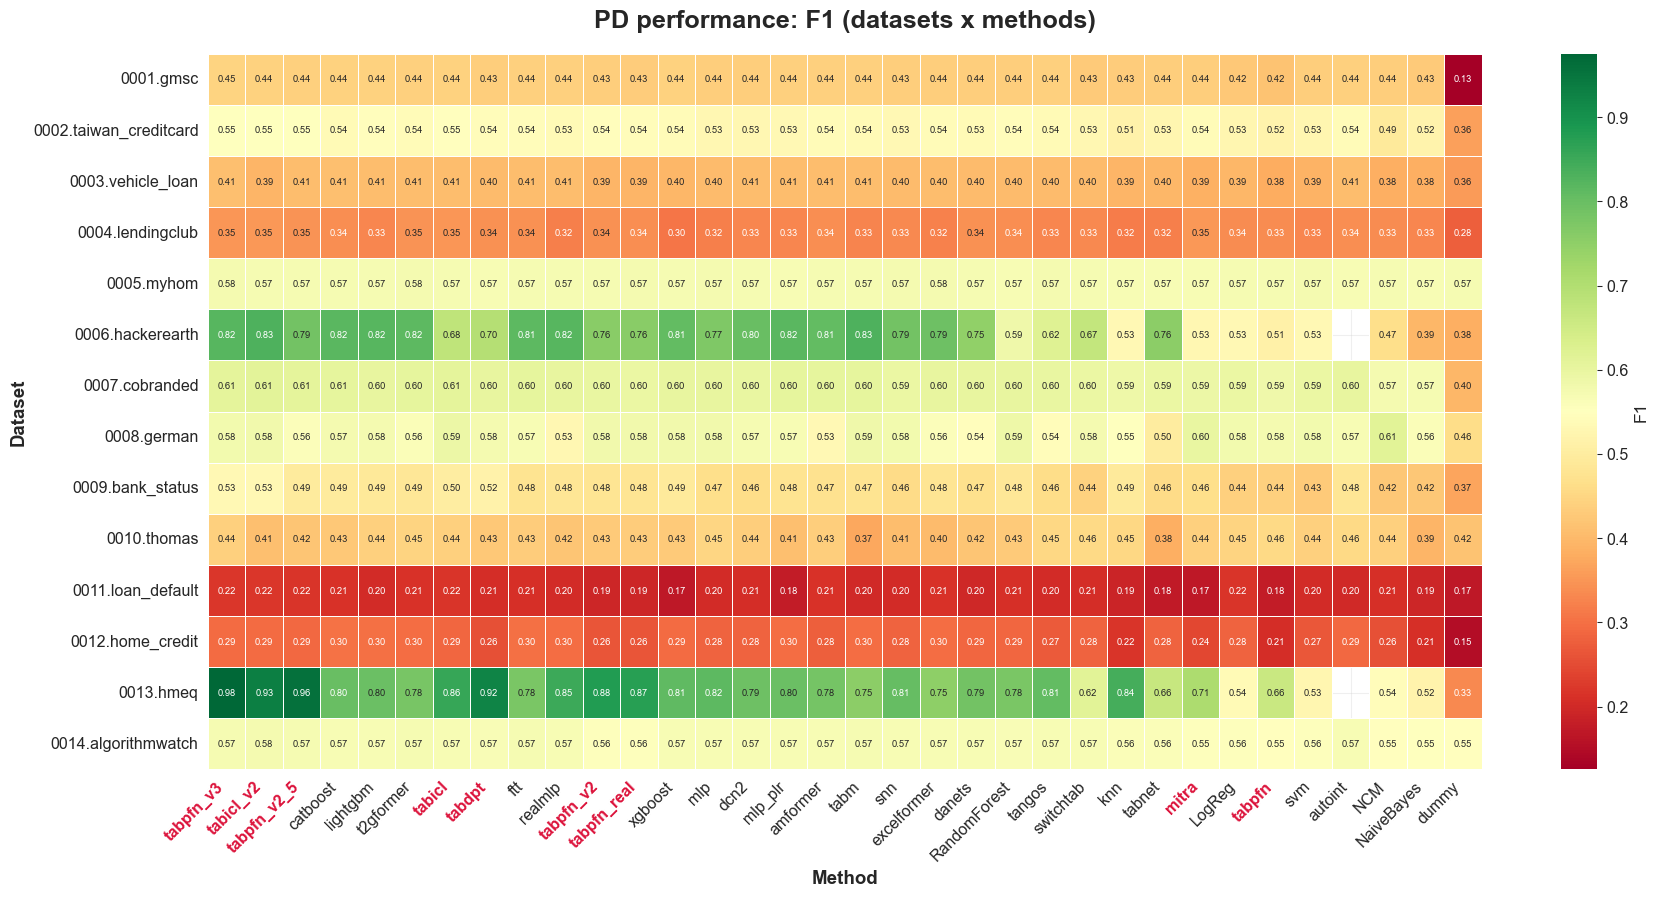

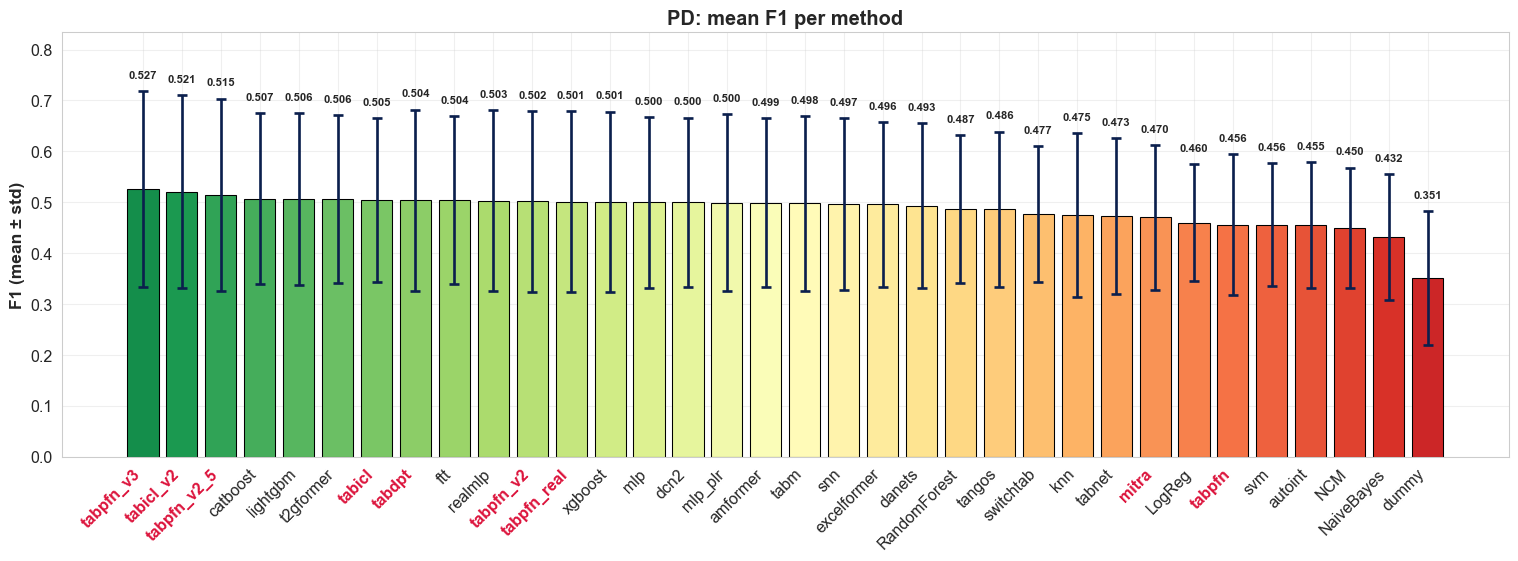

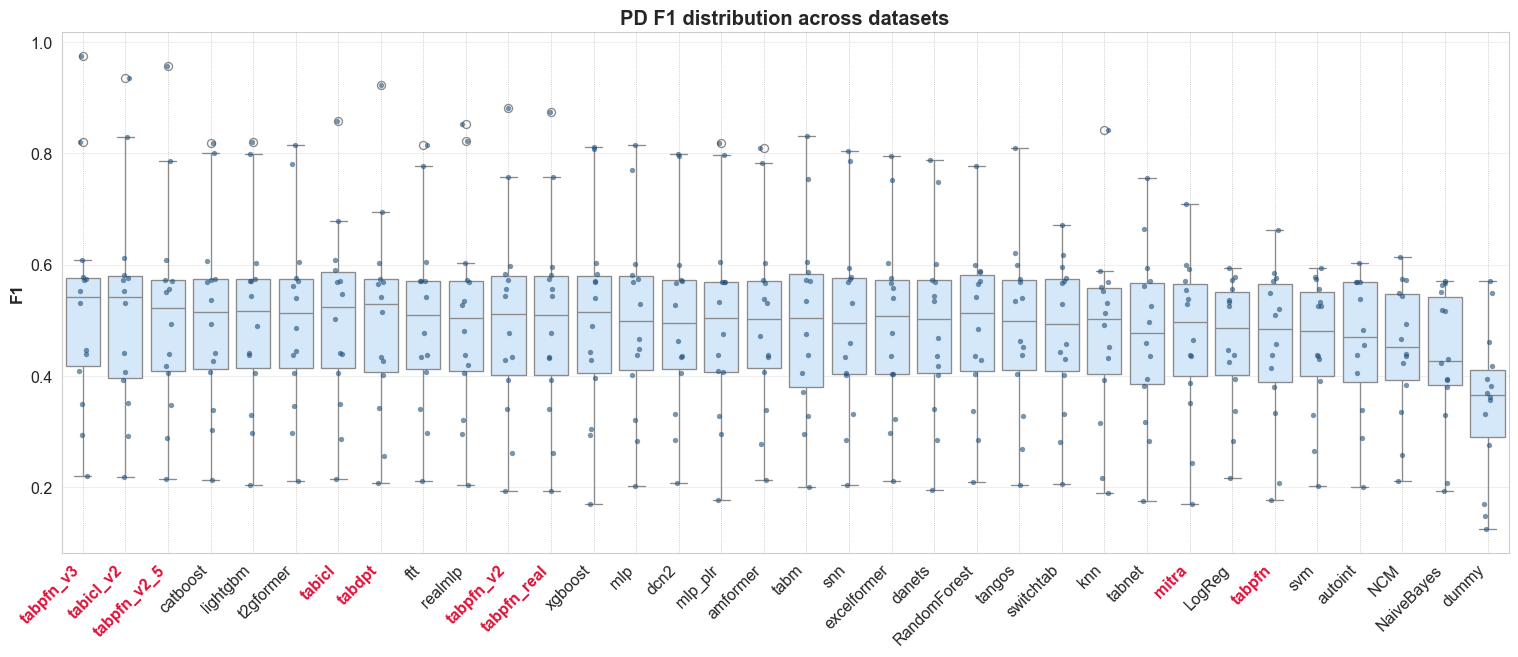

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_f1.pdf')

In [5]:
performance_heatmap(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'F1', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)

## Compute time (fit + predict, seconds; log scale)

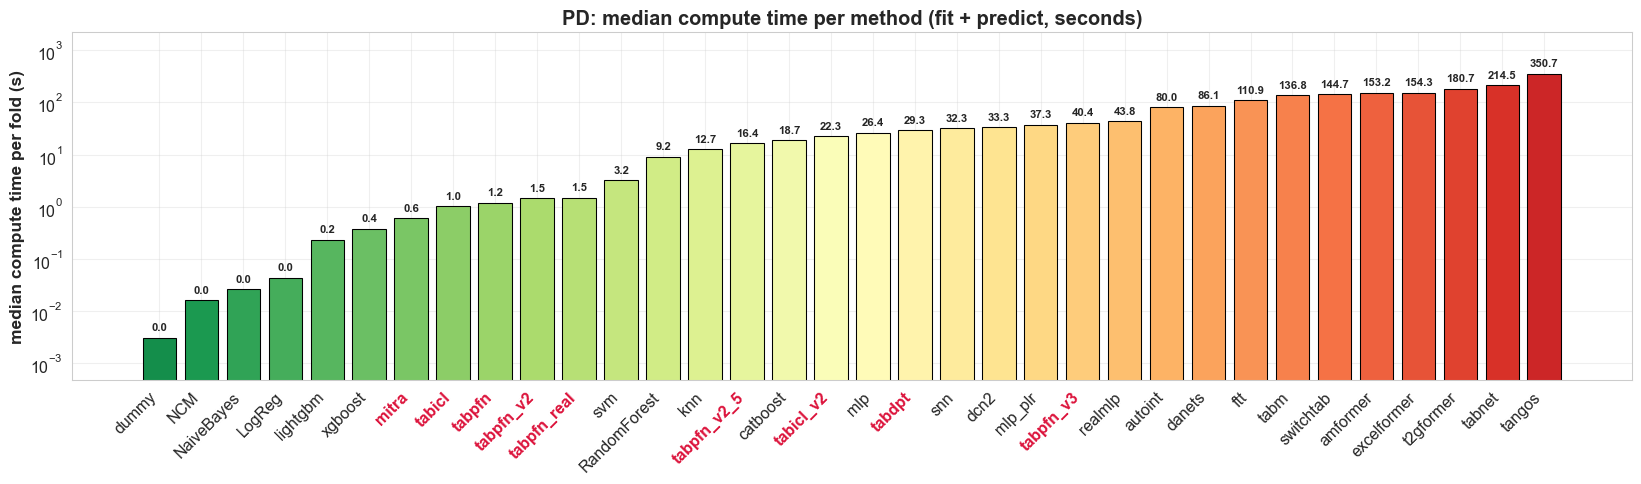

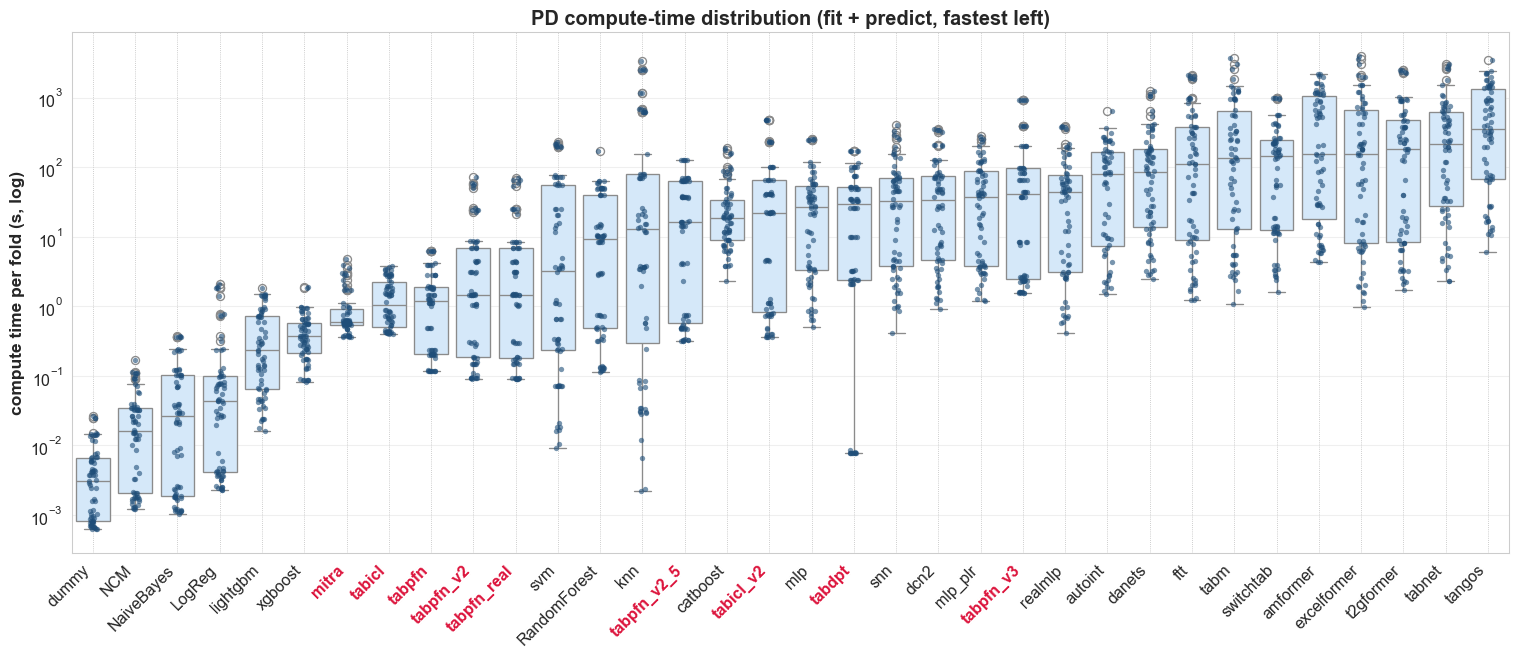

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_box_compute_time.pdf')

In [6]:
compute_time_bars(df, task_name='PD', out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='PD', out_dir=FIGURES_DIR)

## Rank by AUC (1 = best on that dataset)

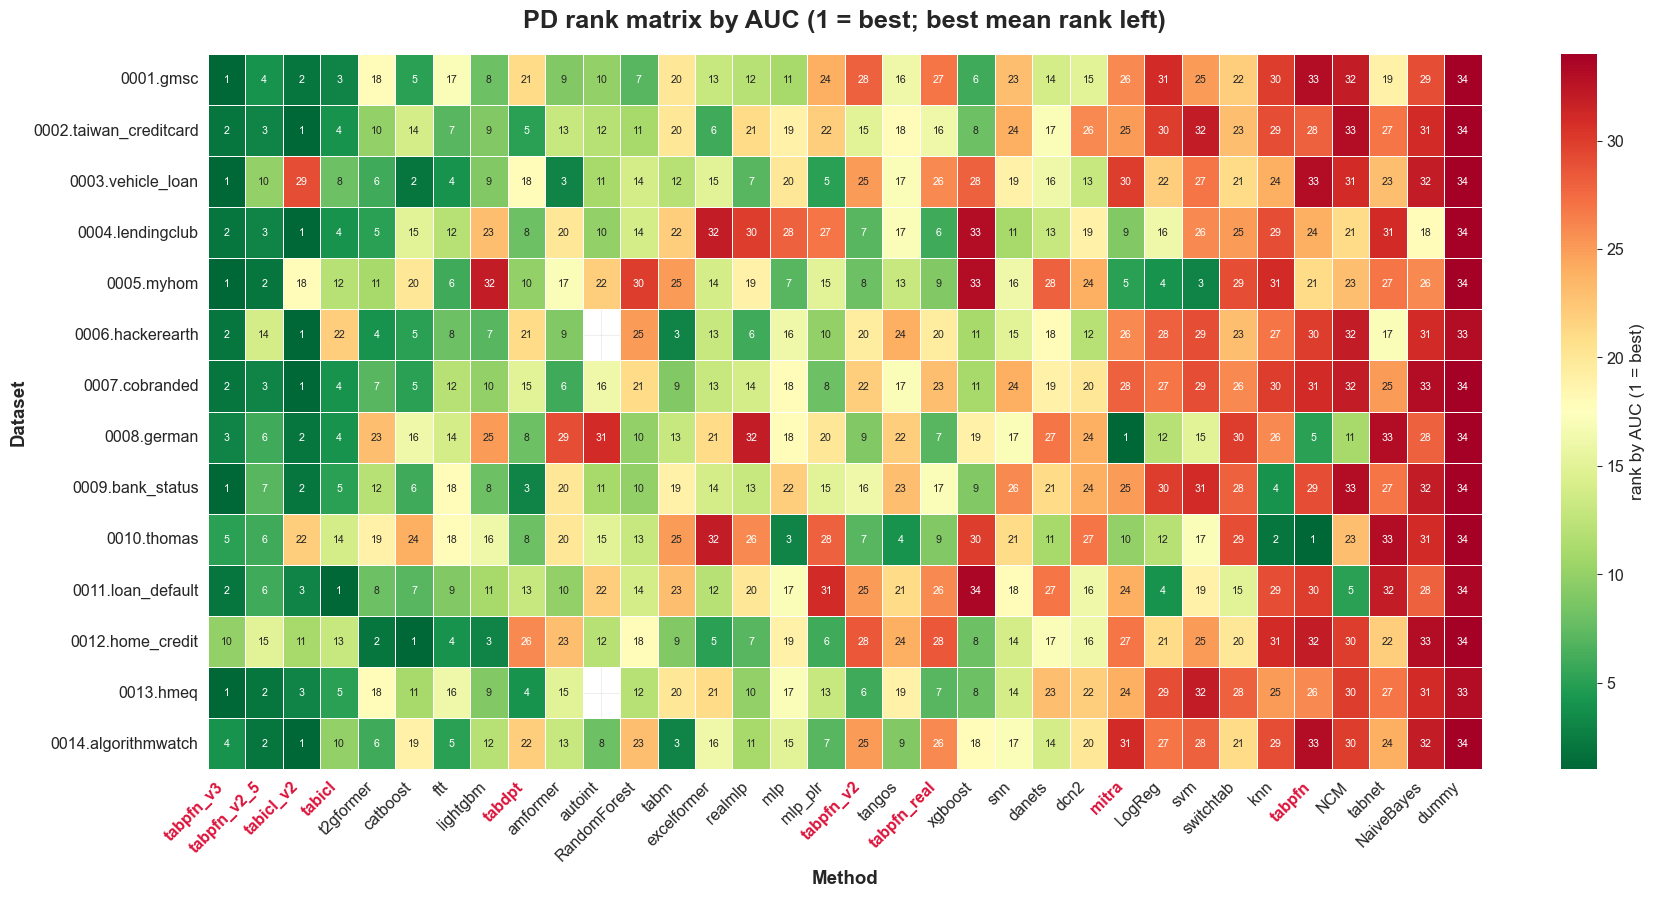

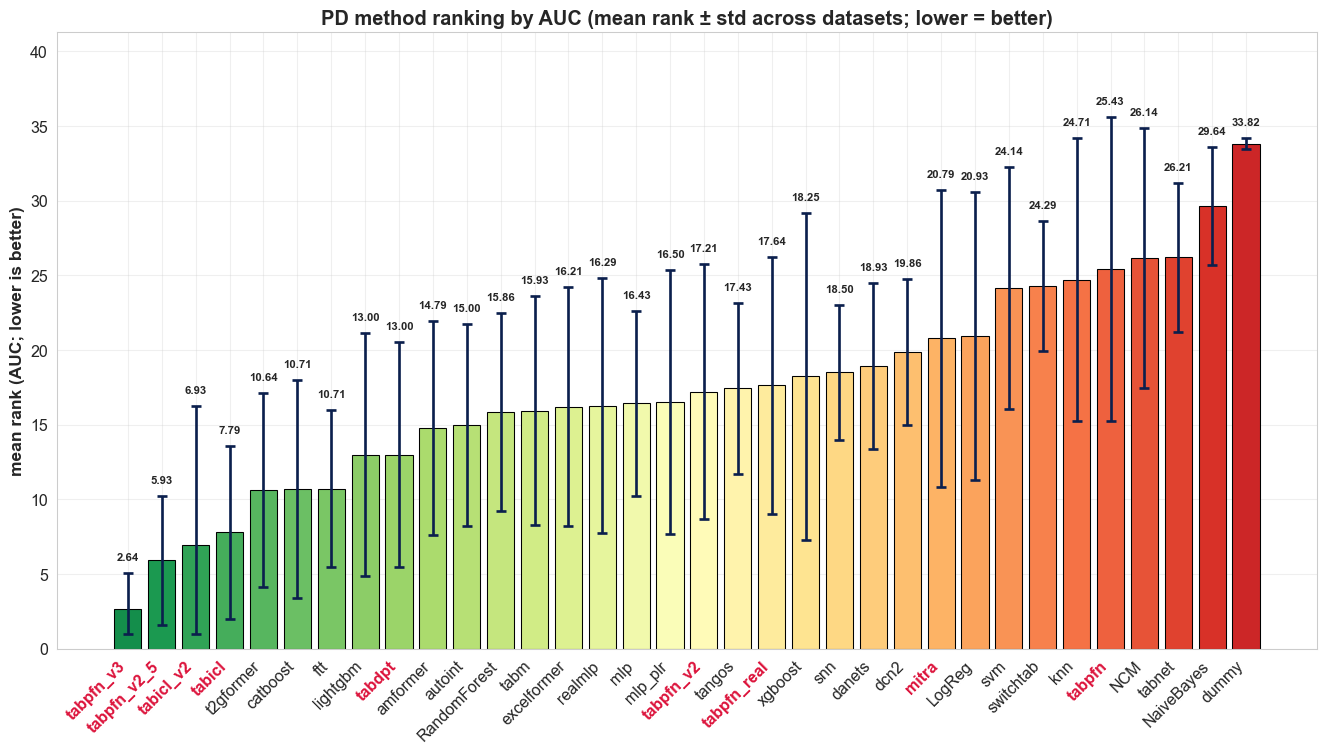

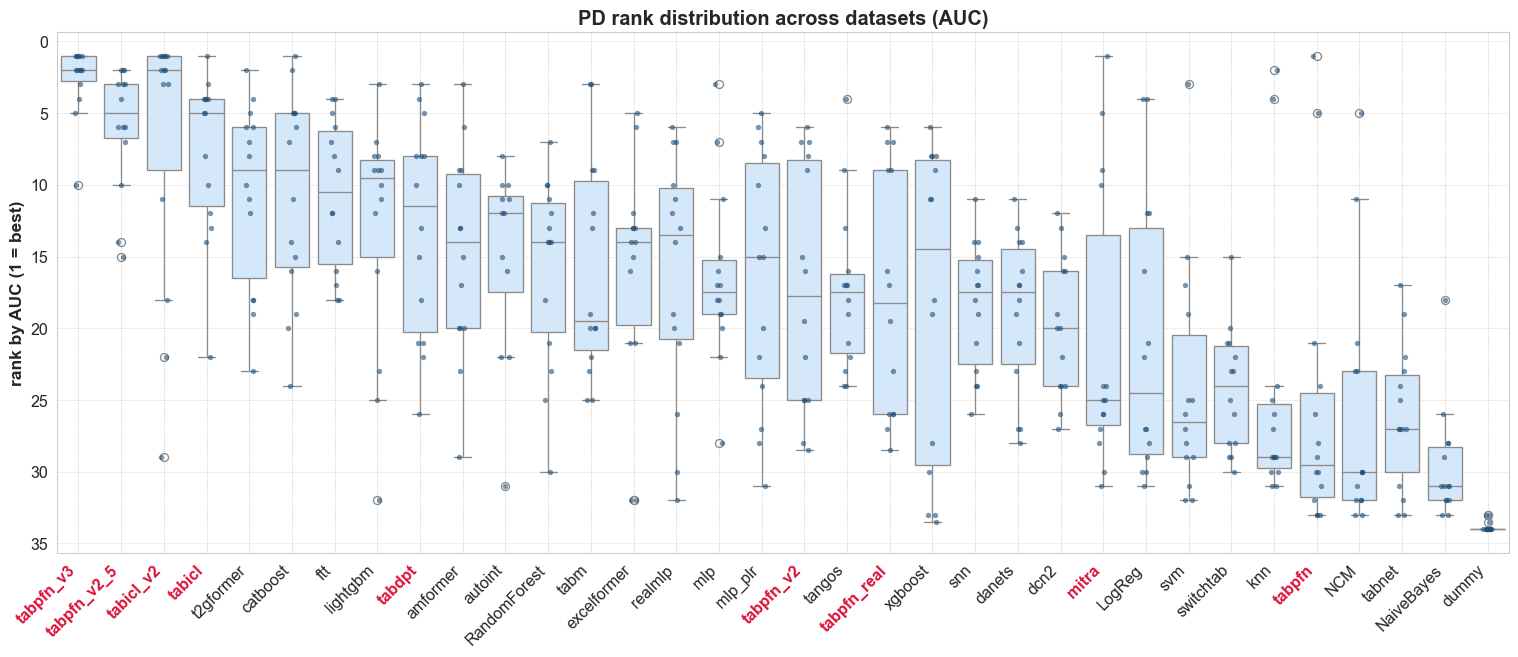

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_rank_box_auc.pdf')

In [7]:
rank_heatmap(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## Effect of HPO on AUC  (foundation models = copies of NO_HPO → 0 by design)

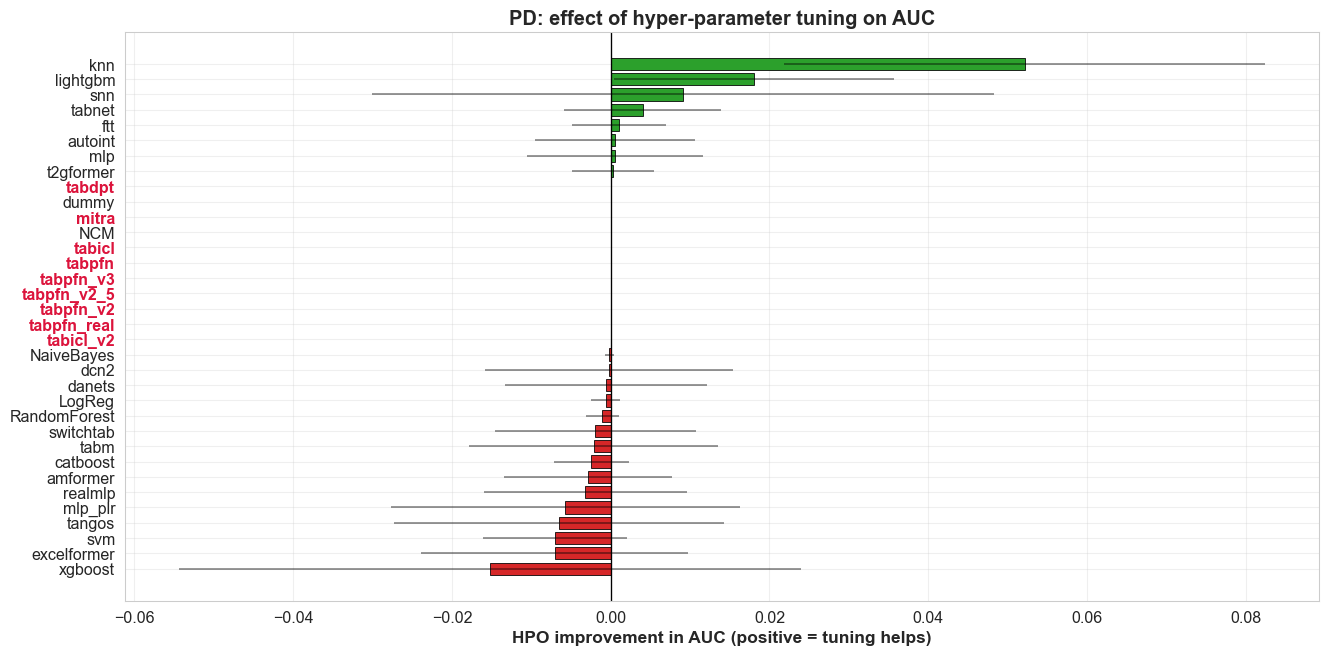

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_hpo_effect_auc.pdf')

In [8]:
hpo_improvement_bars(df_both, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## Performance vs compute time

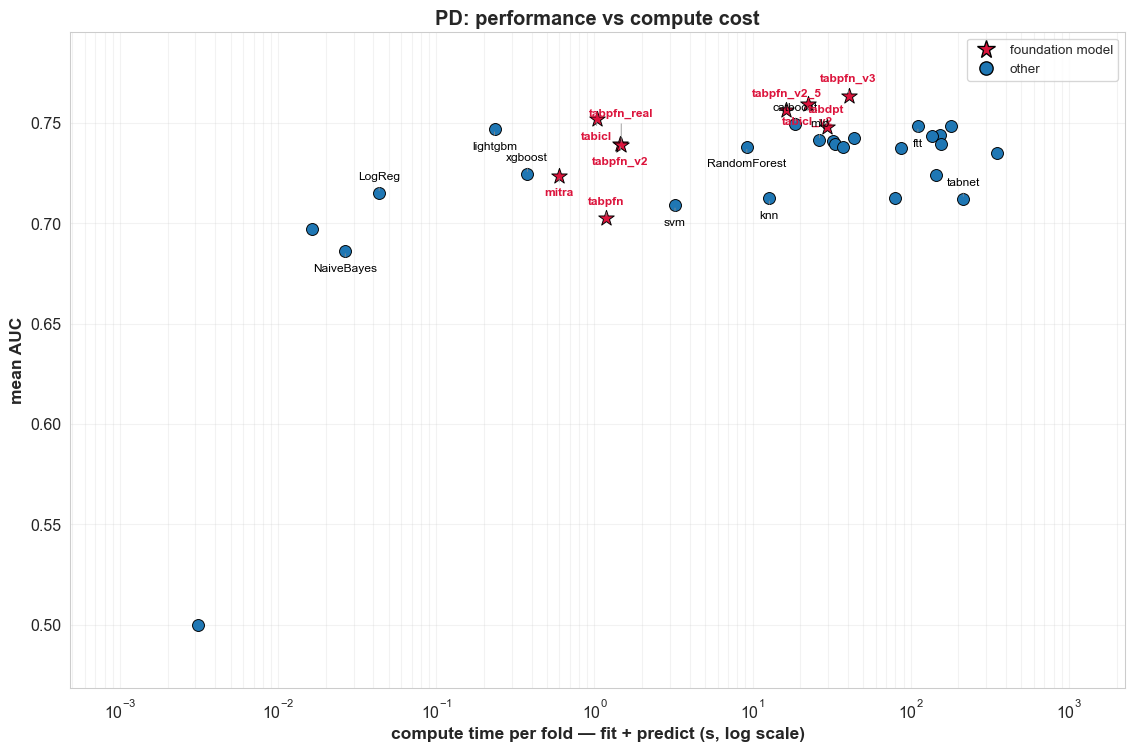

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/pd/pd_cost_quality_auc.pdf')

In [9]:
runtime_performance_scatter(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## Summary

In [10]:
pd_summary_text(df, task_name='Experiment 1 — PD')

Experiment 1 — PD — mean of every metric per method   (datasets: 14, methods: 34)
                 AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Optimal_Threshold  Avg_Precision  Precision  Recall  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure      AP  AP_baseline  AP_minus_baseline  time_s (median)
method                                                                                                                                                                                                                                                                                                                
tabpfn_v3     0.7636  0.5272  0.4244         0.3758  0.5266    0.7252             0.6899  0.3563  0.1255  0.0237   0.3896             0.2389            NaN     0.4581  0.6722                    0.7286                    0.1657      -8180.9257     0.2980  0.5120       0.2207             0.2914   

'Experiment 1 — PD — mean of every metric per method   (datasets: 14, methods: 34)\n=================================================================================\n                 AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Optimal_Threshold  Avg_Precision  Precision  Recall  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure      AP  AP_baseline  AP_minus_baseline  time_s (median)\nmethod                                                                                                                                                                                                                                                                                                                \ntabpfn_v3     0.7636  0.5272  0.4244         0.3758  0.5266    0.7252             0.6899  0.3563  0.1255  0.0237   0.3896             0.2389            NaN     0.4581  0.6722                    0.7286         